In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/telco_churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows:
0


In [10]:
print("Blank TotalCharges:")
print(df["TotalCharges"].str.strip().eq("").sum())

Blank TotalCharges:
11


In [11]:
print("\nNon-numeric TotalCharges:")
print(
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()
)


Non-numeric TotalCharges:
11


In [12]:
print("\nRows with blank TotalCharges:")
print(df[df["TotalCharges"].str.strip() == ""])


Rows with blank TotalCharges:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service            

In [13]:
blank_rows = df[df["TotalCharges"].str.strip() == ""]

print(blank_rows[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [16]:
print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 0


In [17]:
print(df.loc[
    df["tenure"] == 0,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           0.0    No
753   3115-CZMZD       0           20.25           0.0    No
936   5709-LVOEQ       0           80.85           0.0    No
1082  4367-NUYAO       0           25.75           0.0    No
1340  1371-DWPAZ       0           56.05           0.0    No
3331  7644-OMVMY       0           19.85           0.0    No
3826  3213-VVOLG       0           25.35           0.0    No
4380  2520-SGTTA       0           20.00           0.0    No
5218  2923-ARZLG       0           19.70           0.0    No
6670  4075-WKNIU       0           73.35           0.0    No
6754  2775-SEFEE       0           61.90           0.0    No


In [18]:
print(df.info())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


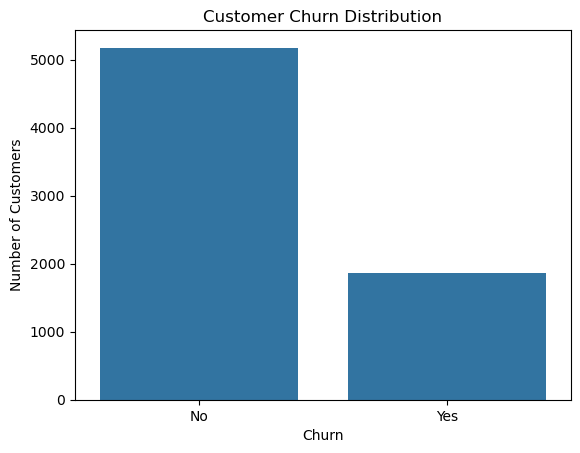

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

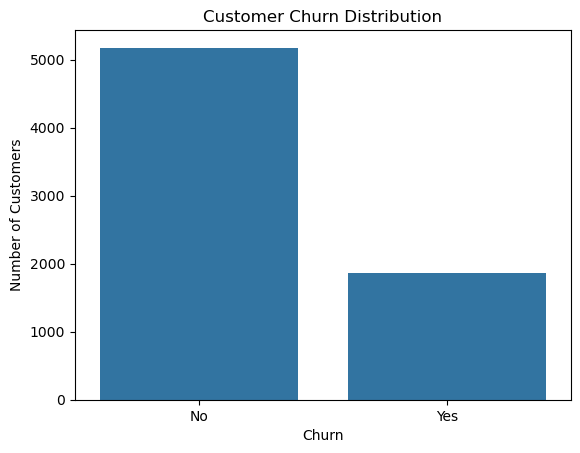

In [20]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [21]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [22]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


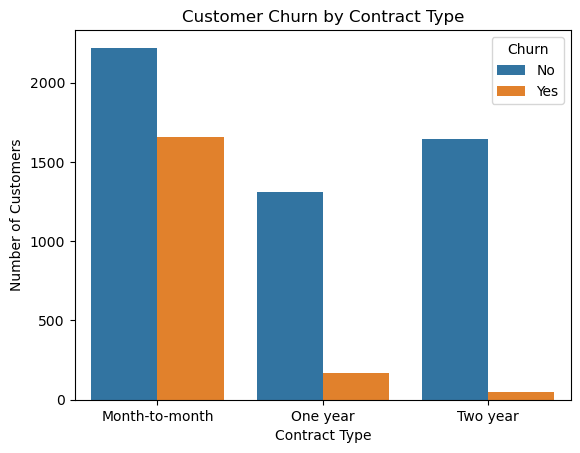

In [23]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

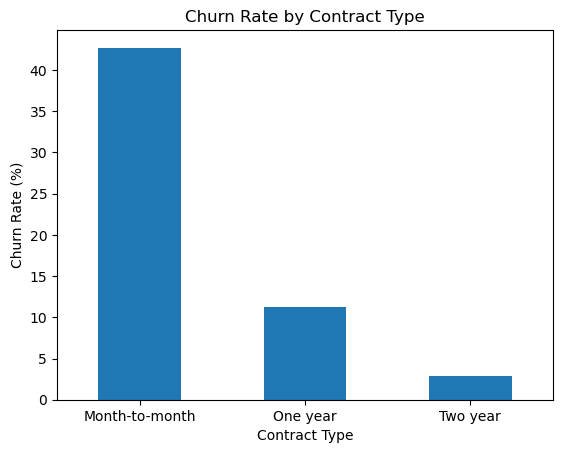

In [24]:
contract_churn["Yes"].plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [25]:
print(df.groupby("Churn")["tenure"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [26]:
print(df.groupby("Churn")["tenure"].median())

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


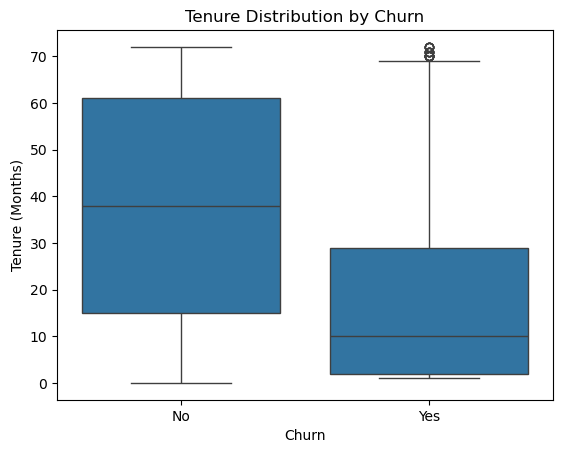

In [27]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [28]:
print(df.groupby("Churn")["MonthlyCharges"].mean())

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [29]:
print(df.groupby("Churn")["MonthlyCharges"].median())

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


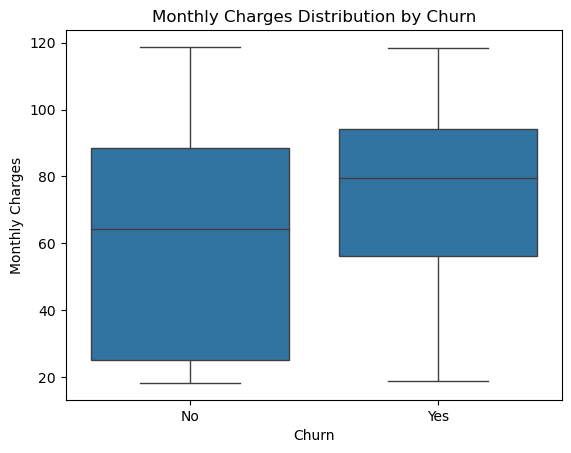

In [30]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [31]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [32]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


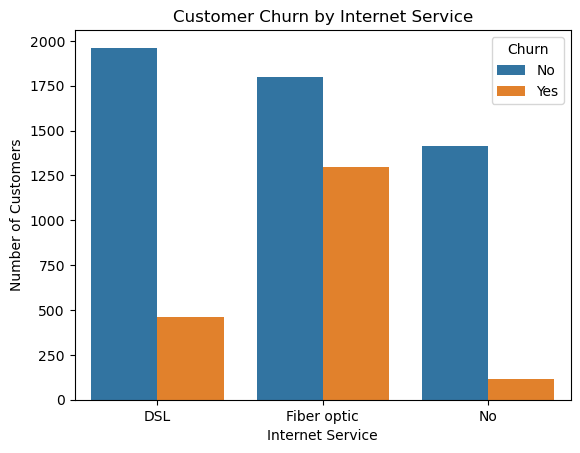

In [33]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

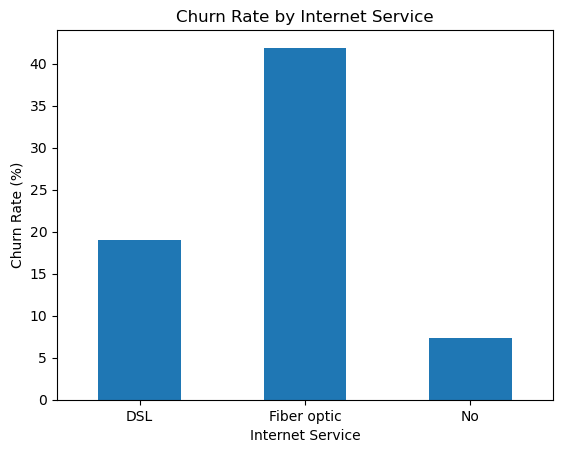

In [34]:
internet_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [35]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [36]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


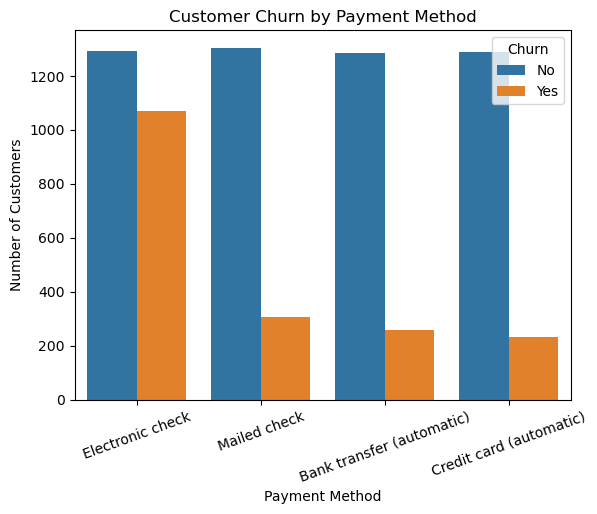

In [37]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

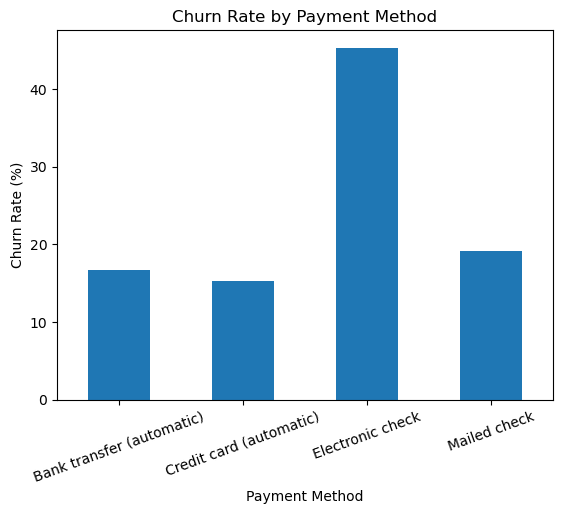

In [38]:
payment_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [39]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(tech_support_churn)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


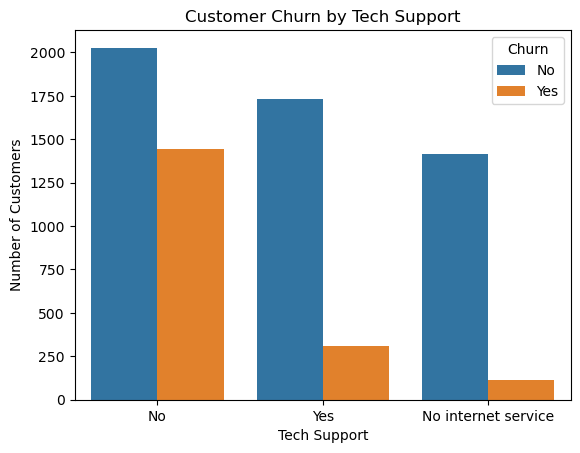

In [40]:
sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

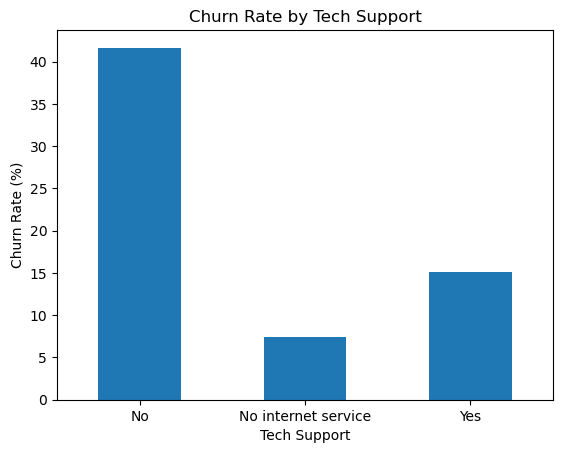

In [41]:
tech_support_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [42]:
online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(online_security_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


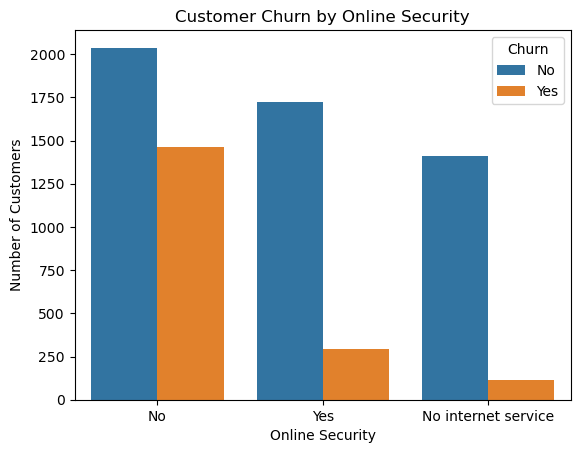

In [43]:
sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

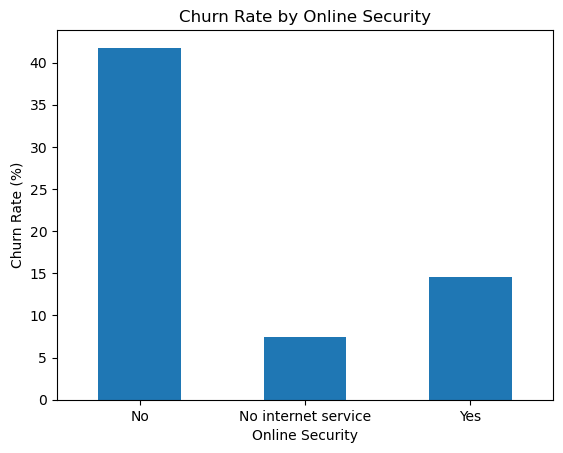

In [44]:
online_security_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [45]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

correlation = df_corr[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.016567        0.220173      0.103006   
tenure               0.016567  1.000000        0.247900      0.826178   
MonthlyCharges       0.220173  0.247900        1.000000      0.651174   
TotalCharges         0.103006  0.826178        0.651174      1.000000   
Churn                0.150889 -0.352229        0.193356     -0.198324   

                   Churn  
SeniorCitizen   0.150889  
tenure         -0.352229  
MonthlyCharges  0.193356  
TotalCharges   -0.198324  
Churn           1.000000  


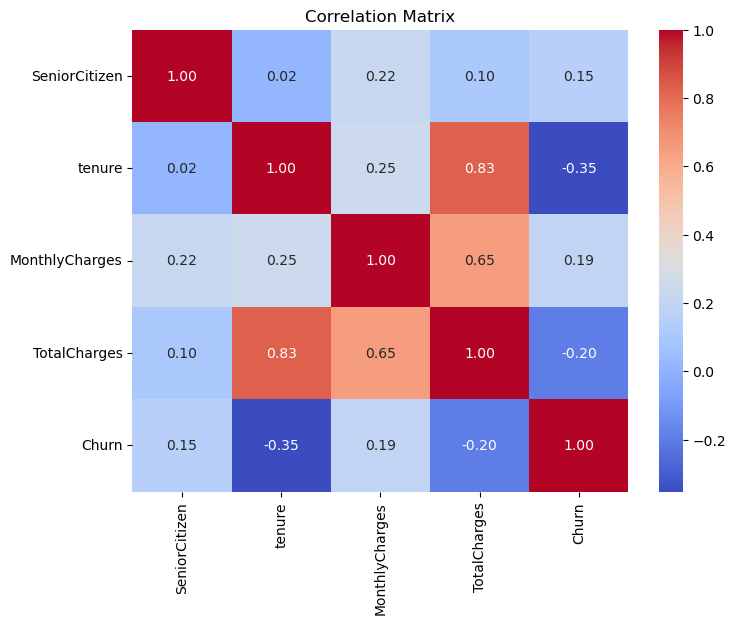

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(["Churn", "customerID"], axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training shape: (5634, 19)
Testing shape: (1409, 19)

Training target distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

X shape: (7043, 19)
y shape: (7043,)
Training shape: (5634, 19)
Testing shape: (1409, 19)

Training distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [52]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [53]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [55]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [56]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (5634, 45)
Testing data shape: (1409, 45)


### Training 1st ML model - Logistic Regression 

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [59]:
logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [60]:
y_pred = logistic_model.predict(X_test_processed)

In [61]:
y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040
ROC-AUC  : 0.8421


### Trainig 2nd Model- Random Forest 

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [65]:
random_forest.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [66]:
y_pred_rf = random_forest.predict(X_test_processed)

In [67]:
y_pred_proba_rf = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [68]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7828
Precision: 0.6189
Recall   : 0.4733
F1 Score : 0.5364
ROC-AUC  : 0.8232


### Training 3rd Model- XGBoost

In [69]:
from xgboost import XGBClassifier

In [70]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [71]:
xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [72]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [73]:
y_pred_proba_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [74]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

XGBoost Results
----------------
Accuracy : 0.8055
Precision: 0.6701
Recall   : 0.5267
F1 Score : 0.5898
ROC-AUC  : 0.8438


In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


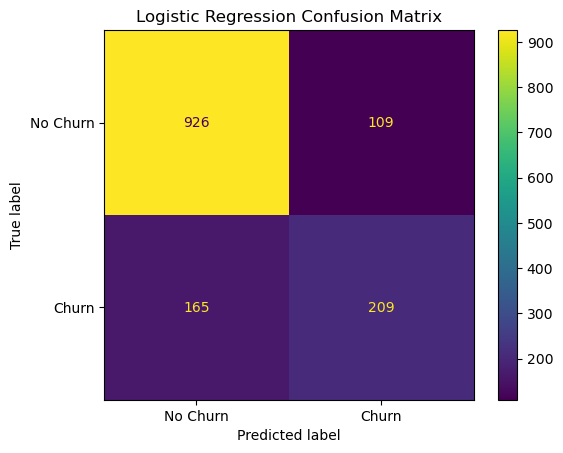

In [76]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Hyperparameter Tuning

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

In [78]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

In [79]:
grid_lr.fit(
    X_train_processed,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced']},
             scoring='roc_auc')

In [80]:
print("Best parameters:")
print(grid_lr.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_lr.best_score_)

Best parameters:
{'C': 100, 'class_weight': None}

Best cross-validation ROC-AUC:
0.8459762402293883


In [81]:
best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_processed)

y_pred_proba_lr_tuned = best_lr.predict_proba(
    X_test_processed
)[:, 1]

In [82]:
accuracy_lr_tuned = accuracy_score(
    y_test,
    y_pred_lr_tuned
)

precision_lr_tuned = precision_score(
    y_test,
    y_pred_lr_tuned
)

recall_lr_tuned = recall_score(
    y_test,
    y_pred_lr_tuned
)

f1_lr_tuned = f1_score(
    y_test,
    y_pred_lr_tuned
)

roc_auc_lr_tuned = roc_auc_score(
    y_test,
    y_pred_proba_lr_tuned
)

print("Tuned Logistic Regression Results")
print("----------------------------------")
print(f"Accuracy : {accuracy_lr_tuned:.4f}")
print(f"Precision: {precision_lr_tuned:.4f}")
print(f"Recall   : {recall_lr_tuned:.4f}")
print(f"F1 Score : {f1_lr_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_lr_tuned:.4f}")

Tuned Logistic Regression Results
----------------------------------
Accuracy : 0.7999
Precision: 0.6438
Recall   : 0.5508
F1 Score : 0.5937
ROC-AUC  : 0.8409


### Tune Random Forest

In [83]:
from sklearn.model_selection import RandomizedSearchCV

In [84]:
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 8, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [85]:
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [87]:
random_search_rf.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 5, 8, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc')

In [88]:
print("Best Random Forest parameters:")
print(random_search_rf.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(random_search_rf.best_score_)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}

Best cross-validation ROC-AUC:
0.8476786707277378


In [89]:
best_rf = random_search_rf.best_estimator_

In [90]:
y_pred_rf_tuned = best_rf.predict(X_test_processed)

y_pred_proba_rf_tuned = best_rf.predict_proba(
    X_test_processed
)[:, 1]

In [91]:
accuracy_rf_tuned = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned
)

f1_rf_tuned = f1_score(
    y_test,
    y_pred_rf_tuned
)

roc_auc_rf_tuned = roc_auc_score(
    y_test,
    y_pred_proba_rf_tuned
)

print("Tuned Random Forest Results")
print("----------------------------")
print(f"Accuracy : {accuracy_rf_tuned:.4f}")
print(f"Precision: {precision_rf_tuned:.4f}")
print(f"Recall   : {recall_rf_tuned:.4f}")
print(f"F1 Score : {f1_rf_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_rf_tuned:.4f}")

Tuned Random Forest Results
----------------------------
Accuracy : 0.7594
Precision: 0.5323
Recall   : 0.7701
F1 Score : 0.6295
ROC-AUC  : 0.8421


In [92]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [93]:
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [94]:
random_search_xgb.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

In [95]:
print("Best XGBoost parameters:")
print(random_search_xgb.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(random_search_xgb.best_score_)

Best XGBoost parameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best cross-validation ROC-AUC:
0.8494716683594309


In [96]:
best_xgb = random_search_xgb.best_estimator_

In [97]:
y_pred_xgb_tuned = best_xgb.predict(X_test_processed)

y_pred_proba_xgb_tuned = best_xgb.predict_proba(
    X_test_processed
)[:, 1]

In [98]:
accuracy_xgb_tuned = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

precision_xgb_tuned = precision_score(
    y_test,
    y_pred_xgb_tuned
)

recall_xgb_tuned = recall_score(
    y_test,
    y_pred_xgb_tuned
)

f1_xgb_tuned = f1_score(
    y_test,
    y_pred_xgb_tuned
)

roc_auc_xgb_tuned = roc_auc_score(
    y_test,
    y_pred_proba_xgb_tuned
)

print("Tuned XGBoost Results")
print("---------------------")
print(f"Accuracy : {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall   : {recall_xgb_tuned:.4f}")
print(f"F1 Score : {f1_xgb_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb_tuned:.4f}")

Tuned XGBoost Results
---------------------
Accuracy : 0.8055
Precision: 0.6724
Recall   : 0.5214
F1 Score : 0.5873
ROC-AUC  : 0.8478


### Using Tuned Random Forest because it has highest F1 score and little diff in ROC-AUC 

### Final Model Pipeline

In [99]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_rf)
    ]
)

In [100]:
print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [101]:
final_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [102]:
y_pred_final = final_pipeline.predict(X_test)

y_pred_proba_final = final_pipeline.predict_proba(
    X_test
)[:, 1]

In [103]:
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print("Final Pipeline Results")
print("----------------------")
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1 Score : {f1_final:.4f}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

Final Pipeline Results
----------------------
Accuracy : 0.7594
Precision: 0.5323
Recall   : 0.7701
F1 Score : 0.6295
ROC-AUC  : 0.8421


In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm_final)

Confusion Matrix:
[[782 253]
 [ 86 288]]


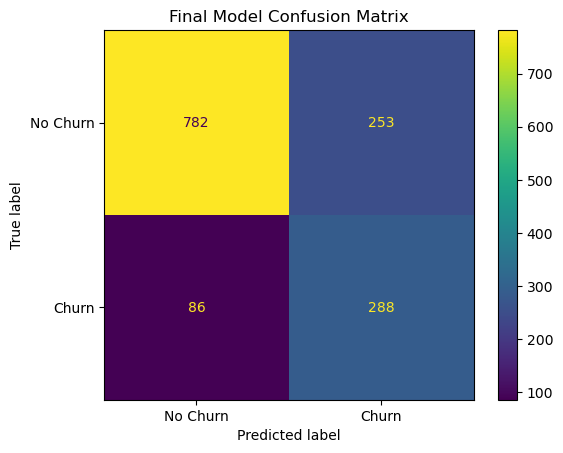

In [105]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Final Model Confusion Matrix")
plt.show()

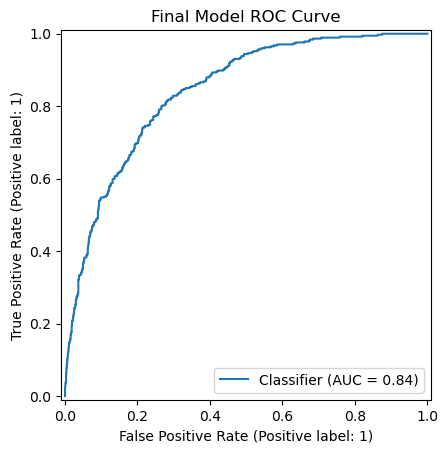

In [106]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_final
)

plt.title("Final Model ROC Curve")
plt.show()

In [107]:
feature_names = final_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [108]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_pipeline.named_steps[
        "model"
    ].feature_importances_
})

In [109]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [110]:
print(feature_importance.head(15))

                                     Feature  Importance
36              cat__Contract_Month-to-month    0.137940
1                                num__tenure    0.126997
3                          num__TotalCharges    0.087457
38                    cat__Contract_Two year    0.075408
18                    cat__OnlineSecurity_No    0.073328
27                       cat__TechSupport_No    0.060508
2                        num__MonthlyCharges    0.058937
16          cat__InternetService_Fiber optic    0.055759
43       cat__PaymentMethod_Electronic check    0.037716
15                  cat__InternetService_DSL    0.020549
37                    cat__Contract_One year    0.019354
21                      cat__OnlineBackup_No    0.019160
34  cat__StreamingMovies_No internet service    0.013489
20                   cat__OnlineSecurity_Yes    0.012452
24                  cat__DeviceProtection_No    0.011250


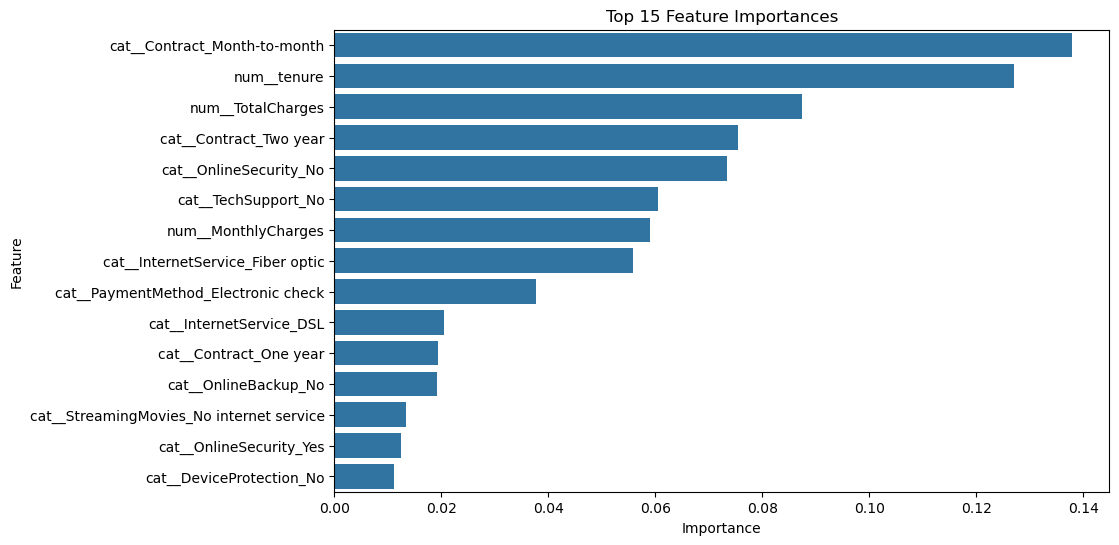

In [111]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [112]:
import joblib

joblib.dump(
    final_pipeline,
    "churn_prediction_pipeline.pkl"
)

['churn_prediction_pipeline.pkl']

In [113]:
import os

print(
    "Model saved:",
    os.path.exists("churn_prediction_pipeline.pkl")
)

Model saved: True


In [114]:
import joblib

loaded_pipeline = joblib.load(
    "churn_prediction_pipeline.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [115]:
loaded_predictions = loaded_pipeline.predict(X_test)

loaded_probabilities = loaded_pipeline.predict_proba(
    X_test
)[:, 1]

print("First 10 predictions:")
print(loaded_predictions[:10])

print("\nFirst 10 churn probabilities:")
print(loaded_probabilities[:10])

First 10 predictions:
[0 1 0 1 0 1 1 0 0 1]

First 10 churn probabilities:
[0.05347962 0.80884715 0.1413405  0.52374517 0.0719318  0.76032854
 0.59405292 0.22988744 0.01226595 0.59565662]


In [116]:
loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

loaded_precision = precision_score(
    y_test,
    loaded_predictions
)

loaded_recall = recall_score(
    y_test,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions
)

loaded_roc_auc = roc_auc_score(
    y_test,
    loaded_probabilities
)

print("Loaded Model Results")
print("--------------------")
print(f"Accuracy : {loaded_accuracy:.4f}")
print(f"Precision: {loaded_precision:.4f}")
print(f"Recall   : {loaded_recall:.4f}")
print(f"F1 Score : {loaded_f1:.4f}")
print(f"ROC-AUC  : {loaded_roc_auc:.4f}")

Loaded Model Results
--------------------
Accuracy : 0.7594
Precision: 0.5323
Recall   : 0.7701
F1 Score : 0.6295
ROC-AUC  : 0.8421


In [117]:
import sklearn
import joblib
import xgboost
import pandas
import numpy

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("xgboost:", xgboost.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

scikit-learn: 1.5.1
joblib: 1.4.2
xgboost: 3.4.0
pandas: 2.2.2
numpy: 1.26.4


In [118]:
import sys

print(sys.executable)

C:\Users\LENOVO\anaconda3\python.exe
